## Setup and Paths

In [3]:
import gc
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RANDOM_STATE = 42

In [4]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/Supply_Chain_Demand_Forecasting"
RAW_DIR = f"{PROJECT_DIR}/data/raw"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"
NOTEBOOK_DIR = f"{PROJECT_DIR}/notebooks"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints/notebook06"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DATA_PATH = f"{PROCESSED_DIR}/cleaned_sales_data.csv"

Mounted at /content/drive


In [5]:
!pip install prophet --quiet
from prophet import Prophet

## Build the Aggregated Series for Teaching

In [6]:
use_cols = ['date', 'store_id', 'item_id', 'state_id', 'units_sold', 'snap', 'sell_price']
df = pd.read_csv(DATA_PATH, usecols=use_cols, parse_dates=['date'],
                  dtype={'store_id': 'category', 'item_id': 'category', 'state_id': 'category',
                         'snap': 'int8', 'units_sold': 'float32', 'sell_price': 'float32'})

daily = df.groupby('date').agg(units_sold=('units_sold', 'sum'), snap=('snap', 'mean')).reset_index()
daily = daily.set_index('date').asfreq('D')

print("Aggregated teaching series:", daily.shape)
daily.head()

Aggregated teaching series: (1941, 2)


,units_sold,snap
date,,
2011-01-29,6893.0,0.00000
2011-01-30,6842.0,0.00000
2011-01-31,4638.0,0.00000
2011-02-01,5309.0,1.00000
2011-02-02,4324.0,0.51147


## Recap: What Item #8

In [7]:
train_size = int(len(daily) * 0.9)
train_series = daily['units_sold'].iloc[:train_size]
test_series = daily['units_sold'].iloc[train_size:]

print(f"Train: {len(train_series)} days | Test: {len(test_series)} days")

Train: 1746 days | Test: 195 days


## Moving Average (Smoothing) vs. MA (Model Component) — Disambiguation

In [8]:
def moving_average_forecast(series, window, horizon):
    """Naive MA smoothing forecast: repeat the trailing window's mean for the whole horizon."""
    last_window_mean = series.iloc[-window:].mean()
    return pd.Series([last_window_mean] * horizon, index=pd.date_range(
        series.index[-1] + pd.Timedelta(days=1), periods=horizon, freq='D'
    ))

ma_smooth_preds = moving_average_forecast(train_series, window=7, horizon=len(test_series))
print(ma_smooth_preds.head())

2015-11-10    7347.285645
2015-11-11    7347.285645
2015-11-12    7347.285645
2015-11-13    7347.285645
2015-11-14    7347.285645
Freq: D, dtype: float32


## AR (AutoRegressive) Model


In [9]:
ar_model = AutoReg(train_series, lags=7, old_names=False).fit()
print(ar_model.summary().tables[1])

ar_preds = ar_model.predict(start=len(train_series), end=len(train_series) + len(test_series) - 1)
ar_preds.index = test_series.index

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           567.7575    146.715      3.870      0.000     280.201     855.314
units_sold.L1     0.3806      0.021     18.069      0.000       0.339       0.422
units_sold.L2    -0.1177      0.022     -5.339      0.000      -0.161      -0.074
units_sold.L3    -0.0175      0.022     -0.794      0.427      -0.061       0.026
units_sold.L4     0.0354      0.022      1.607      0.108      -0.008       0.079
units_sold.L5    -0.1061      0.022     -4.819      0.000      -0.149      -0.063
units_sold.L6     0.2670      0.022     12.142      0.000       0.224       0.310
units_sold.L7     0.4768      0.021     22.670      0.000       0.436       0.518


## MA(q) Model Component

In [10]:
ma_model = ARIMA(train_series, order=(0, 0, 7)).fit()
print(ma_model.summary().tables[1])

ma_preds = ma_model.forecast(steps=len(test_series))
ma_preds.index = test_series.index

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       6906.4100     61.834    111.693      0.000    6785.217    7027.603
ma.L1          0.4769      0.017     28.160      0.000       0.444       0.510
ma.L2          0.0596      0.021      2.889      0.004       0.019       0.100
ma.L3         -0.0413      0.022     -1.867      0.062      -0.085       0.002
ma.L4         -0.0082      0.022     -0.376      0.707      -0.051       0.035
ma.L5          0.0607      0.020      2.999      0.003       0.021       0.100
ma.L6          0.4171      0.020     20.363      0.000       0.377       0.457
ma.L7          0.4987      0.020     25.013      0.000       0.460       0.538
sigma2      1.045e+06   2.34e+04     44.575      0.000    9.99e+05    1.09e+06


## ARMA Model

In [11]:
arma_model = ARIMA(train_series, order=(7, 0, 1)).fit()
arma_preds = arma_model.forecast(steps=len(test_series))
arma_preds.index = test_series.index

print(f"AIC — AR: {ar_model.aic:.1f} | MA: {ma_model.aic:.1f} | ARMA: {arma_model.aic:.1f}")

AIC — AR: 28147.8 | MA: 29174.3 | ARMA: 28257.5


## ARIMA Model (Adding Differencing)

In [12]:
arima_model = ARIMA(train_series, order=(7, 1, 1)).fit()
arima_preds = arima_model.forecast(steps=len(test_series))
arima_preds.index = test_series.index

print(arima_model.summary().tables[0])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:             units_sold   No. Observations:                 1746
Model:                 ARIMA(7, 1, 1)   Log Likelihood              -14098.787
Date:                Wed, 15 Jul 2026   AIC                          28215.574
Time:                        22:14:01   BIC                          28264.755
Sample:                    01-29-2011   HQIC                         28233.757
                         - 11-09-2015                                         
Covariance Type:                  opg                                         


## SARIMA (Seasonal ARIMA)

In [13]:
sarima_model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),  # s=7, directly from Item #8's ACF weekly spike
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_preds = sarima_model.forecast(steps=len(test_series))
sarima_preds.index = test_series.index

print(sarima_model.summary().tables[0])

                                     SARIMAX Results                                     
Dep. Variable:                        units_sold   No. Observations:                 1746
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -13693.005
Date:                           Wed, 15 Jul 2026   AIC                          27396.009
Time:                                   22:14:11   BIC                          27423.286
Sample:                               01-29-2011   HQIC                         27406.098
                                    - 11-09-2015                                         
Covariance Type:                             opg                                         


## SARIMAX (Adding Exogenous Regressors)

In [14]:
exog_train = train_series.to_frame().join(daily[['snap']]).drop(columns='units_sold')
exog_test = test_series.to_frame().join(daily[['snap']]).drop(columns='units_sold')

sarimax_model = SARIMAX(
    train_series,
    exog=exog_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarimax_preds = sarimax_model.forecast(steps=len(test_series), exog=exog_test)
sarimax_preds.index = test_series.index

print(sarimax_model.summary().tables[1].as_text()[:800])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
snap         769.5902     45.626     16.867      0.000     680.166     859.015
ar.L1          0.1986      0.014     14.519      0.000       0.172       0.225
ma.L1         -0.9441      0.010    -97.041      0.000      -0.963      -0.925
ar.S.L7        0.1152      0.019      6.136      0.000       0.078       0.152
ma.S.L7       -0.9682      0.007   -142.308      0.000      -0.982      -0.955
sigma2      3.564e+05   4149.251     85.886      0.000    3.48e+05    3.64e+05


## Prophet

In [15]:
prophet_train_df = train_series.reset_index().rename(columns={'date': 'ds', 'units_sold': 'y'})
prophet_train_df = prophet_train_df.merge(daily[['snap']].reset_index().rename(columns={'date': 'ds'}), on='ds')

prophet_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
prophet_model.add_regressor('snap')
prophet_model.fit(prophet_train_df)

future = test_series.reset_index()[['date']].rename(columns={'date': 'ds'})
future = future.merge(daily[['snap']].reset_index().rename(columns={'date': 'ds'}), on='ds')
prophet_forecast = prophet_model.predict(future)

prophet_preds = pd.Series(prophet_forecast['yhat'].values, index=test_series.index)

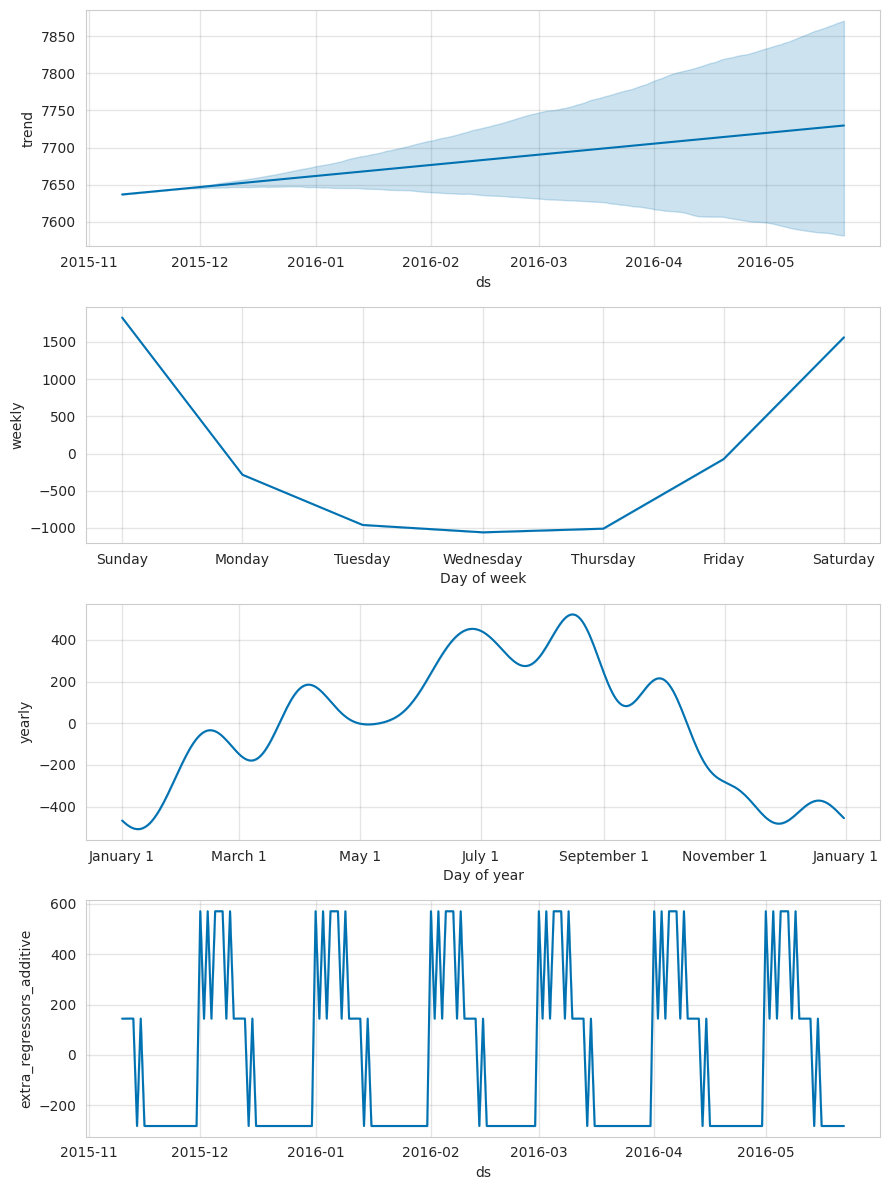

In [16]:
prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

## Compare All Classical Models (Teaching Series)

In [17]:
def wmape(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(actual)

teaching_results = []
model_preds = {
    'moving_average_smoothing': ma_smooth_preds,
    'ar': ar_preds,
    'ma': ma_preds,
    'arma': arma_preds,
    'arima': arima_preds,
    'sarima': sarima_preds,
    'sarimax': sarimax_preds,
    'prophet': prophet_preds,
}

for name, preds in model_preds.items():
    preds = preds.reindex(test_series.index)
    mae = mean_absolute_error(test_series, preds)
    rmse = np.sqrt(mean_squared_error(test_series, preds))
    w = wmape(test_series.values, preds.values)
    teaching_results.append({'model': name, 'mae': mae, 'rmse': rmse, 'wmape': w})

teaching_comparison = pd.DataFrame(teaching_results).sort_values('wmape')
teaching_comparison

,model,mae,rmse,wmape
7,prophet,523.967386,811.096505,0.069688
5,sarima,661.904015,949.520338,0.088034
6,sarimax,786.687027,1041.513499,0.104630
4,arima,958.370678,1369.426284,0.127464
1,ar,1015.257072,1479.443017,0.135030
3,arma,1018.921302,1497.368512,0.135517
2,ma,1130.204146,1613.541916,0.150318
0,moving_average_smoothing,1147.857910,1508.449535,0.152666


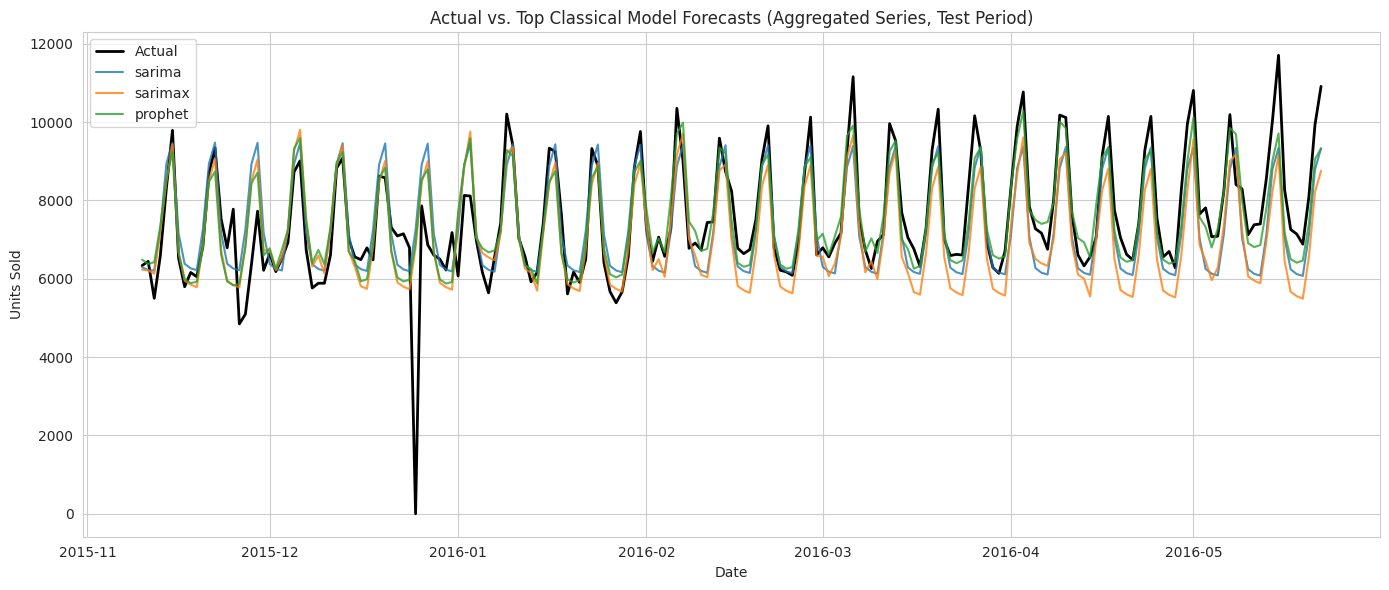

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(test_series.index, test_series.values, label='Actual', linewidth=2, color='black')
for name in ['sarima', 'sarimax', 'prophet']:
    plt.plot(test_series.index, model_preds[name].reindex(test_series.index), label=name, alpha=0.8)
plt.title('Actual vs. Top Classical Model Forecasts (Aggregated Series, Test Period)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

##  Stratified Panel Sample: SARIMA and Prophet Across Volume Tiers (Final Fold Only)

In [19]:
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/classical_model_metrics_checkpoint.csv"

field_counts = {}
if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, 'r') as f:
        for line in f:
            n_fields = len(line.strip().split(','))
            field_counts[n_fields] = field_counts.get(n_fields, 0) + 1

print("Field count distribution across all lines:", field_counts)

Field count distribution across all lines: {7: 361}


In [20]:
import shutil

if os.path.exists(CHECKPOINT_PATH):
    backup_path = CHECKPOINT_PATH.replace('.csv', '_corrupted_backup.csv')
    shutil.move(CHECKPOINT_PATH, backup_path)
    print(f"Moved corrupted checkpoint to: {backup_path}")
else:
    print("No checkpoint file found — nothing to reset.")

completed = set()
print("Checkpoint reset. Ready to re-run Section 12's sampling and training loop.")

Moved corrupted checkpoint to: /content/drive/MyDrive/Supply_Chain_Demand_Forecasting/checkpoints/notebook06/classical_model_metrics_checkpoint_corrupted_backup.csv
Checkpoint reset. Ready to re-run Section 12's sampling and training loop.


In [21]:
CHECKPOINT_PATH = f"{CHECKPOINT_DIR}/classical_model_metrics_checkpoint.csv"

panel_df = pd.read_csv(DATA_PATH, usecols=['date', 'store_id', 'item_id', 'units_sold', 'snap'],
                        parse_dates=['date'],
                        dtype={'store_id': 'category', 'item_id': 'category',
                               'snap': 'int8', 'units_sold': 'float32'})
panel_df.sort_values(['store_id', 'item_id', 'date'], inplace=True)
panel_df.reset_index(drop=True, inplace=True)

FORECAST_HORIZON = 28
unique_dates = np.sort(panel_df['date'].unique())
tscv = TimeSeriesSplit(n_splits=5, test_size=FORECAST_HORIZON)
final_fold = list(tscv.split(unique_dates))[-1]
train_end_date = unique_dates[final_fold[0][-1]]
test_start_date = unique_dates[final_fold[1][0]]
test_end_date = unique_dates[final_fold[1][-1]]

del unique_dates
gc.collect()

print(f"Final fold: train ends {pd.Timestamp(train_end_date).date()} | "
      f"test {pd.Timestamp(test_start_date).date()} -> {pd.Timestamp(test_end_date).date()}")

Final fold: train ends 2016-04-24 | test 2016-04-25 -> 2016-05-22


In [22]:
# Stratified sample by total volume: split all series into 3 volume tiers
# (high/medium/low), sample proportionally from each -- guarantees the panel
# benchmark represents the full demand spectrum, not just top-sellers.
SAMPLE_SIZE = 180

volume_by_series = (
    panel_df.groupby(['store_id', 'item_id'], observed=True)['units_sold']
    .sum()
    .reset_index()
    .rename(columns={'units_sold': 'total_volume'})
)
volume_by_series = volume_by_series[volume_by_series['total_volume'] > 0]  # drop dead series entirely

volume_by_series['volume_tier'] = pd.qcut(
    volume_by_series['total_volume'], q=3, labels=['low', 'medium', 'high']
)

series_keys = (
    volume_by_series.groupby('volume_tier', observed=True, group_keys=False)
    .apply(lambda g: g.sample(n=min(SAMPLE_SIZE // 3, len(g)), random_state=RANDOM_STATE))
    .reset_index(drop=True)
)[['store_id', 'item_id', 'volume_tier']]

print(f"Sampled {len(series_keys)} series ({series_keys['volume_tier'].value_counts().to_dict()})")
series_keys.head()

Sampled 180 series ({'low': 60, 'medium': 60, 'high': 60})


/tmp/ipykernel_1369/2277811873.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=min(SAMPLE_SIZE // 3, len(g)), random_state=RANDOM_STATE))


,store_id,item_id,volume_tier
0,CA_1,HOUSEHOLD_2_156,low
1,CA_1,FOODS_3_017,low
2,TX_1,FOODS_3_821,low
3,TX_1,HOBBIES_2_103,low
4,CA_1,HOUSEHOLD_2_480,low


In [23]:
if os.path.exists(CHECKPOINT_PATH):
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    completed = set(zip(checkpoint_df['store_id'], checkpoint_df['item_id'], checkpoint_df['model']))
else:
    completed = set()

print(f"Resuming: {len(completed)} of {len(series_keys) * 2} series-model results already checkpointed.")

Resuming: 0 of 360 series-model results already checkpointed.


In [24]:
SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 7)

def wmape(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(actual)

for idx, row in series_keys.iterrows():
    store_id, item_id, tier = row['store_id'], row['item_id'], row['volume_tier']

    if (store_id, item_id, 'sarima') in completed and (store_id, item_id, 'prophet') in completed:
        continue

    series_df = panel_df[(panel_df['store_id'] == store_id) & (panel_df['item_id'] == item_id)]
    train_s = series_df[series_df['date'] <= train_end_date].set_index('date')['units_sold'].asfreq('D').fillna(0)
    test_s = series_df[(series_df['date'] >= test_start_date) & (series_df['date'] <= test_end_date)]
    test_s = test_s.set_index('date')['units_sold'].asfreq('D').fillna(0)

    if len(train_s) < 60 or len(test_s) == 0:
        del series_df, train_s, test_s
        continue

    if (store_id, item_id, 'sarima') not in completed:
        try:
            model = SARIMAX(train_s, order=SARIMA_ORDER, seasonal_order=SARIMA_SEASONAL_ORDER,
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            preds = model.forecast(steps=len(test_s)).clip(lower=0)
            mae = mean_absolute_error(test_s, preds)
            rmse = np.sqrt(mean_squared_error(test_s, preds))
            w = wmape(test_s.values, preds.values)
        except Exception:
            mae, rmse, w = np.nan, np.nan, np.nan

        pd.DataFrame([{
            'store_id': store_id, 'item_id': item_id, 'volume_tier': tier, 'model': 'sarima',
            'mae': mae, 'rmse': rmse, 'wmape': w
        }]).to_csv(CHECKPOINT_PATH, mode='a', header=not os.path.exists(CHECKPOINT_PATH), index=False)
        completed.add((store_id, item_id, 'sarima'))
        del model, preds
        gc.collect()

    if (store_id, item_id, 'prophet') not in completed:
        try:
            p_train = train_s.reset_index().rename(columns={'date': 'ds', 'units_sold': 'y'})
            p_model = Prophet(weekly_seasonality=True, yearly_seasonality=False, daily_seasonality=False)
            p_model.fit(p_train)
            p_future = test_s.reset_index()[['date']].rename(columns={'date': 'ds'})
            p_forecast = p_model.predict(p_future)
            p_preds = pd.Series(p_forecast['yhat'].clip(lower=0).values, index=test_s.index)

            mae = mean_absolute_error(test_s, p_preds)
            rmse = np.sqrt(mean_squared_error(test_s, p_preds))
            w = wmape(test_s.values, p_preds.values)
        except Exception:
            mae, rmse, w = np.nan, np.nan, np.nan

        pd.DataFrame([{
            'store_id': store_id, 'item_id': item_id, 'volume_tier': tier, 'model': 'prophet',
            'mae': mae, 'rmse': rmse, 'wmape': w
        }]).to_csv(CHECKPOINT_PATH, mode='a', header=not os.path.exists(CHECKPOINT_PATH), index=False)
        completed.add((store_id, item_id, 'prophet'))
        del p_model, p_forecast, p_preds
        gc.collect()

    del series_df, train_s, test_s
    if idx % 20 == 0:
        gc.collect()
        print(f"Progress: {idx}/{len(series_keys)} series processed.")

print("\nAll sampled series processed (or already complete from a previous run).")

Progress: 0/180 series processed.


/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)
/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Progress: 20/180 series processed.
Progress: 40/180 series processed.


/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)
/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)
/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)
/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)


Progress: 60/180 series processed.
Progress: 80/180 series processed.
Progress: 100/180 series processed.
Progress: 120/180 series processed.


/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)
/tmp/ipykernel_1369/1844297309.py:5: RuntimeWarning: divide by zero encountered in scalar divide
  return np.sum(np.abs(actual - predicted)) / np.sum(actual)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Progress: 140/180 series processed.
Progress: 160/180 series processed.

All sampled series processed (or already complete from a previous run).


## Aggregate Stratified Sample Results and Save

In [25]:
# Reload the panel data needed to recompute actual sums (cheap -- filtered to sampled series only)
panel_recheck = pd.read_csv(
    DATA_PATH, usecols=['date', 'store_id', 'item_id', 'units_sold'],
    parse_dates=['date'],
    dtype={'store_id': 'category', 'item_id': 'category', 'units_sold': 'float32'}
)
panel_recheck = panel_recheck[
    (panel_recheck['date'] >= test_start_date) & (panel_recheck['date'] <= test_end_date)
]
panel_recheck = panel_recheck.merge(series_keys, on=['store_id', 'item_id'], how='inner')

actual_sums = (
    panel_recheck.groupby(['store_id', 'item_id'], observed=True)['units_sold']
    .sum()
    .reset_index()
    .rename(columns={'units_sold': 'actual_sum'})
)

del panel_recheck
gc.collect()

n_zero_demand = (actual_sums['actual_sum'] == 0).sum()
print(f"Series with zero actual demand in the test window: {n_zero_demand} of {len(actual_sums)}")

Series with zero actual demand in the test window: 4 of 180


In [26]:
classical_df = pd.read_csv(CHECKPOINT_PATH)

# n_test is fixed at 28 for every series (asfreq('D') over the same fixed test window),
# so sum(abs error) = mae * 28 exactly.
classical_df = classical_df.merge(actual_sums, on=['store_id', 'item_id'], how='left')
classical_df['sum_abs_error'] = classical_df['mae'] * 28

# Pooled WMAPE per model (overall)
pooled_overall = (
    classical_df.groupby('model')
    .apply(lambda g: g['sum_abs_error'].sum() / g['actual_sum'].sum(), include_groups=False)
    .rename('pooled_wmape')
)
print("Pooled WMAPE (overall, zero-demand-safe):")
print((pooled_overall * 100).round(2))

Pooled WMAPE (overall, zero-demand-safe):
model
prophet    70.81
sarima     68.30
Name: pooled_wmape, dtype: float64


In [27]:
# Pooled WMAPE per model, per volume tier
pooled_by_tier = (
    classical_df.groupby(['volume_tier', 'model'])
    .apply(lambda g: g['sum_abs_error'].sum() / g['actual_sum'].sum(), include_groups=False)
    .rename('pooled_wmape')
    .reset_index()
)
pooled_by_tier['pooled_wmape_pct'] = (pooled_by_tier['pooled_wmape'] * 100).round(2)
pooled_by_tier.pivot(index='volume_tier', columns='model', values='pooled_wmape_pct')

model,prophet,sarima
volume_tier,,
high,60.07,56.60
low,134.71,134.51
medium,99.14,100.59


In [28]:
expected_total = len(series_keys) * 2
if len(completed) == expected_total:
    FINAL_OUT_PATH = f"{PROCESSED_DIR}/classical_model_metrics.csv"
    classical_df.to_csv(FINAL_OUT_PATH, index=False)
    print("All sampled series complete. Saved classical_model_metrics.csv —", classical_df.shape)
else:
    print(f"WARNING: {expected_total - len(completed)} series-model results still incomplete.")

All sampled series complete. Saved classical_model_metrics.csv — (360, 9)


In [29]:
del classical_df
gc.collect()

31

### Key Takeaways

- On the aggregated total-demand series, Prophet achieved the best fit (6.97% WMAPE) versus
  SARIMA (8.80%), driven by its automatic yearly+weekly seasonality decomposition — while
  SARIMAX underperformed plain SARIMA (10.46%), indicating the SNAP exogenous signal is too
  weak at the aggregate level to improve on an already-strong seasonal specification.

- At panel scale (180-series stratified sample, final fold), the result reversed: SARIMA
  outperformed Prophet overall (68.30% vs. 70.81% pooled WMAPE), suggesting SARIMA's explicit
  autoregressive error-correction generalizes better to noisy, individual-series-level demand
  than Prophet's smoother curve-fitting approach — a finding that depends on aggregation level,
  not a universal ranking.

- Forecast difficulty scales clearly with volume tier for both models (high: ~57-60% WMAPE,
  medium: ~99-101%, low: ~135% WMAPE), consistent with the intermittent-demand pattern
  identified in Item #5. 4 of 180 sampled series (2.2%) had zero actual demand across their
  entire 28-day test window, requiring a pooled WMAPE calculation (sum of errors / sum of
  actuals) rather than an average of per-series ratios, which is undefined when actual
  demand is zero.

- Classical model panel performance (68-71% WMAPE) sits in a similar range to Item #13's
  full-catalog ML models (70-74% WMAPE) -- whether the ML approach's full-catalog scalability
  outweighs a modest accuracy gap, or whether per-series classical models are competitive
  enough to justify their added operational complexity, is the central question for Item #15's
  three-way comparison.